# AlphaEval Demo — End-to-End Alpha Model Evaluation

This notebook demonstrates the full workflow:
1. **EDA** — Load and explore daily bar data using DuckDB
2. **Feature Engineering** — Compute returns, MA & EMA features per instrument
3. **Classification Model** — Train a Buy/Hold/Sell classifier
4. **AlphaEval** — Evaluate model predictions using the `alphaeval` library

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "data/bars_1d_clean.parquet"

## 1. Exploratory Data Analysis

### 1.1 Schema & basic statistics

In [2]:
duckdb.sql(f"DESCRIBE SELECT * FROM '{DATA_PATH}'")

┌─────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type │  null   │   key   │ default │  extra  │
│   varchar   │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ date        │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ insref      │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ open        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ high        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ low         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ close       │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ volume      │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ ntrades     │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ turnover    │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [3]:
duckdb.sql(f"""
    SELECT
        count(*)            AS total_rows,
        count(DISTINCT insref) AS n_instruments,
        min(date)           AS first_date,
        max(date)           AS last_date,
        count(DISTINCT date) AS n_trading_days
    FROM '{DATA_PATH}'
""")

┌────────────┬───────────────┬────────────┬────────────┬────────────────┐
│ total_rows │ n_instruments │ first_date │ last_date  │ n_trading_days │
│   int64    │     int64     │    date    │    date    │     int64      │
├────────────┼───────────────┼────────────┼────────────┼────────────────┤
│    3422775 │          2127 │ 2015-01-02 │ 2026-03-23 │           2819 │
└────────────┴───────────────┴────────────┴────────────┴────────────────┘

In [4]:
duckdb.sql(f"SELECT * FROM '{DATA_PATH}' LIMIT 10")

┌────────────┬────────┬────────┬────────┬────────┬────────┬───────────┬─────────┬────────────────────┐
│    date    │ insref │  open  │  high  │  low   │ close  │  volume   │ ntrades │      turnover      │
│    date    │ int32  │ double │ double │ double │ double │  double   │ double  │       double       │
├────────────┼────────┼────────┼────────┼────────┼────────┼───────────┼─────────┼────────────────────┤
│ 2015-01-02 │      3 │   4.29 │   4.39 │   4.03 │   4.16 │   73615.0 │    53.0 │          311462.52 │
│ 2015-01-05 │      3 │   4.24 │    4.8 │   4.24 │    4.6 │  201435.0 │   111.0 │          914149.98 │
│ 2015-01-07 │      3 │    4.7 │    5.4 │   4.34 │   5.05 │  553327.0 │   274.0 │ 2762113.4400000004 │
│ 2015-01-08 │      3 │    5.1 │    5.2 │    4.9 │    5.0 │  525563.0 │   217.0 │         2657327.45 │
│ 2015-01-09 │      3 │   4.96 │   5.05 │   4.75 │   4.97 │  100688.0 │    69.0 │          500911.05 │
│ 2015-01-12 │      3 │    5.1 │    7.2 │    5.1 │   6.65 │ 1738581.0 │  

### 1.2 Per-instrument coverage & volume distribution

In [5]:
# Per-instrument summary: number of trading days, median daily volume, avg close
instrument_stats = duckdb.sql(f"""
    SELECT
        insref,
        count(*)        AS n_days,
        median(volume)  AS median_volume,
        avg(close)      AS avg_close,
        min(date)       AS first_date,
        max(date)       AS last_date
    FROM '{DATA_PATH}'
    GROUP BY insref
    ORDER BY n_days DESC
""").df()

print(f"Instruments: {len(instrument_stats)}")
instrument_stats.describe()

Instruments: 2127


,insref,n_days,median_volume,avg_close,first_date,last_date
count,2.127000e+03,2127.000000,2.127000e+03,2127.000000,2127,2127
mean,2.158819e+06,1609.203103,1.425241e+05,101.215375,2017-05-27 08:30:27.926657,2024-08-27 12:05:45.275035
min,3.000000e+00,1.000000,1.000000e+00,0.025632,2015-01-02 00:00:00,2015-01-26 00:00:00
25%,5.057000e+03,762.500000,2.758000e+03,4.710516,2015-01-02 00:00:00,2024-06-01 12:00:00
50%,9.499740e+05,1600.000000,1.361550e+04,18.250674,2015-06-18 00:00:00,2026-03-23 00:00:00
75%,4.313324e+06,2662.500000,6.577750e+04,77.196137,2019-10-23 12:00:00,2026-03-23 00:00:00
max,8.381867e+06,2819.000000,1.387059e+07,12096.883420,2026-03-17 00:00:00,2026-03-23 00:00:00
std,2.437223e+06,969.788851,5.867851e+05,497.951873,NaN,NaN


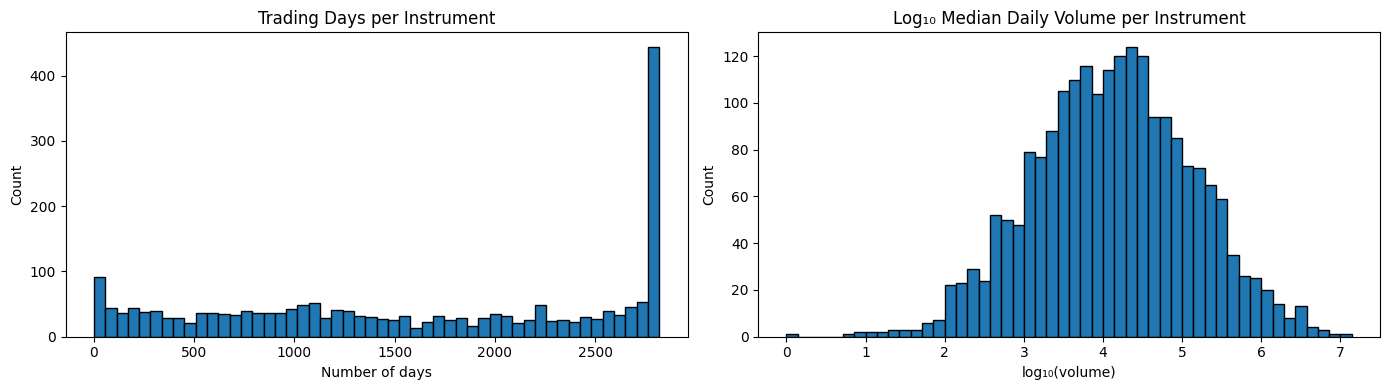

In [6]:
# Distribution of trading days per instrument
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(instrument_stats["n_days"], bins=50, edgecolor="black")
axes[0].set_title("Trading Days per Instrument")
axes[0].set_xlabel("Number of days")
axes[0].set_ylabel("Count")

axes[1].hist(np.log10(instrument_stats["median_volume"].clip(lower=1)), bins=50, edgecolor="black")
axes[1].set_title("Log₁₀ Median Daily Volume per Instrument")
axes[1].set_xlabel("log₁₀(volume)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 1.3 Close price & daily return distributions (sample instrument)

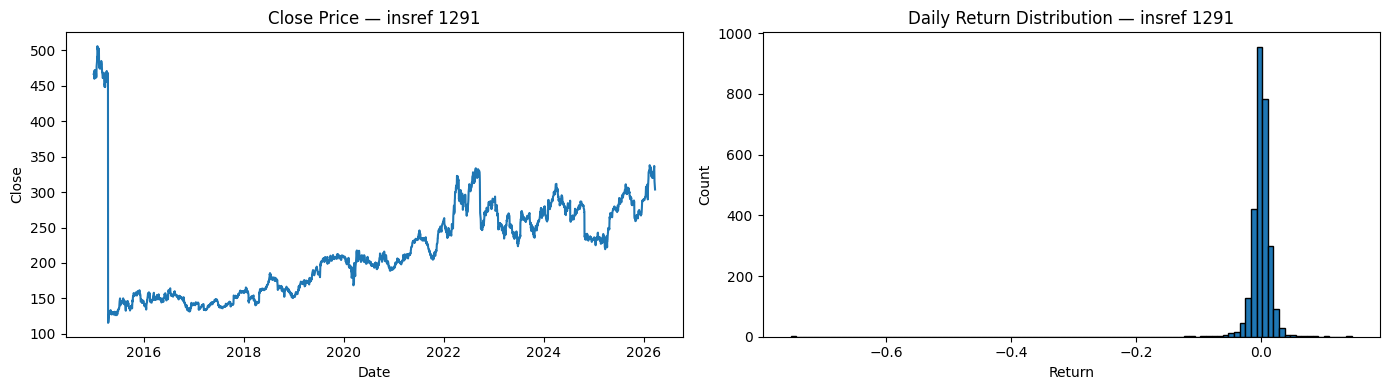

In [7]:
# Pick the instrument with the most trading days as sample
sample_insref = int(instrument_stats.iloc[0]["insref"])
sample = duckdb.sql(f"""
    SELECT * FROM '{DATA_PATH}'
    WHERE insref = {sample_insref}
    ORDER BY date
""").df()

sample["daily_return"] = sample["close"].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sample["date"], sample["close"])
axes[0].set_title(f"Close Price — insref {sample_insref}")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Close")

axes[1].hist(sample["daily_return"].dropna(), bins=100, edgecolor="black")
axes[1].set_title(f"Daily Return Distribution — insref {sample_insref}")
axes[1].set_xlabel("Return")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 2. Data Loading & Feature Engineering

We load all data into pandas, then compute per-instrument:
- **Daily simple return** from close prices
- **Moving Averages** (MA): 10, 20, 50, 100, 200
- **Exponential Moving Averages** (EMA): 10, 20, 50, 100, 200
- **Cross-over signals**: close vs MA/EMA (above = bullish, below = bearish)

In [8]:
# Load full dataset and sort
df = duckdb.sql(f"""
    SELECT * FROM '{DATA_PATH}'
    ORDER BY insref, date
""").df()

print(f"Loaded {len(df):,} rows, {df['insref'].nunique()} instruments")
df.head()

Loaded 3,422,775 rows, 2127 instruments


,date,insref,open,high,low,close,volume,ntrades,turnover
0,2015-01-02,3,4.29,4.39,4.03,4.16,73615.0,53.0,311462.52
1,2015-01-05,3,4.24,4.80,4.24,4.60,201435.0,111.0,914149.98
2,2015-01-07,3,4.70,5.40,4.34,5.05,553327.0,274.0,2762113.44
3,2015-01-08,3,5.10,5.20,4.90,5.00,525563.0,217.0,2657327.45
4,2015-01-09,3,4.96,5.05,4.75,4.97,100688.0,69.0,500911.05


In [9]:
MA_WINDOWS = [10, 20, 50, 100, 200]

# Compute features per instrument using groupby
grouped = df.groupby("insref")

# Daily simple return
df["return"] = grouped["close"].pct_change()

# Moving Averages & EMA
for w in MA_WINDOWS:
    df[f"ma_{w}"]  = grouped["close"].transform(lambda s, win=w: s.rolling(win).mean())
    df[f"ema_{w}"] = grouped["close"].transform(lambda s, win=w: s.ewm(span=win, adjust=False).mean())

# Relative position of close vs MA/EMA (normalized distance)
for w in MA_WINDOWS:
    df[f"close_vs_ma_{w}"]  = (df["close"] - df[f"ma_{w}"])  / df[f"ma_{w}"]
    df[f"close_vs_ema_{w}"] = (df["close"] - df[f"ema_{w}"]) / df[f"ema_{w}"]

# Volume z-score (rolling 20-day)
df["volume_zscore"] = grouped["volume"].transform(
    lambda s: (s - s.rolling(20).mean()) / s.rolling(20).std()
)

# Drop rows with NaN features (warm-up period)
feature_cols = (
    ["return", "volume_zscore"]
    + [f"close_vs_ma_{w}" for w in MA_WINDOWS]
    + [f"close_vs_ema_{w}" for w in MA_WINDOWS]
)
df_feat = df.dropna(subset=feature_cols).copy()

print(f"After feature warmup: {len(df_feat):,} rows, {df_feat['insref'].nunique()} instruments")
df_feat[["date", "insref", "close", "return"] + feature_cols[:6]].head(10)

After feature warmup: 3,023,417 rows, 1925 instruments


,date,insref,close,return,return,volume_zscore,close_vs_ma_10,close_vs_ma_20,close_vs_ma_50,close_vs_ma_100
199,2015-10-26,3,0.735,0.027972,0.027972,-0.051935,-0.076053,-0.100367,-0.126456,-0.117594
200,2015-10-27,3,0.695,-0.054422,-0.054422,2.282233,-0.110115,-0.143825,-0.171732,-0.166667
201,2015-10-28,3,0.685,-0.014388,-0.014388,0.852514,-0.106327,-0.150124,-0.181014,-0.179690
202,2015-10-29,3,0.765,0.116788,0.116788,0.244539,0.009235,-0.047323,-0.084600,-0.085803
203,2015-10-30,3,0.615,-0.196078,-0.196078,2.514384,-0.164969,-0.223730,-0.262413,-0.265233
204,2015-11-02,3,0.575,-0.065041,-0.065041,3.016614,-0.191280,-0.263293,-0.308645,-0.312489
205,2015-11-03,3,0.580,0.008696,0.008696,2.112367,-0.157589,-0.244792,-0.299263,-0.306262
206,2015-11-04,3,0.570,-0.017241,-0.017241,-0.084891,-0.144786,-0.242021,-0.308168,-0.318019
207,2015-11-05,3,0.555,-0.026316,-0.026316,0.776943,-0.144838,-0.248222,-0.322096,-0.335290
208,2015-11-06,3,0.530,-0.045045,-0.045045,-0.124268,-0.159397,-0.264144,-0.349693,-0.364127


### 2.1 Feature correlation heatmap

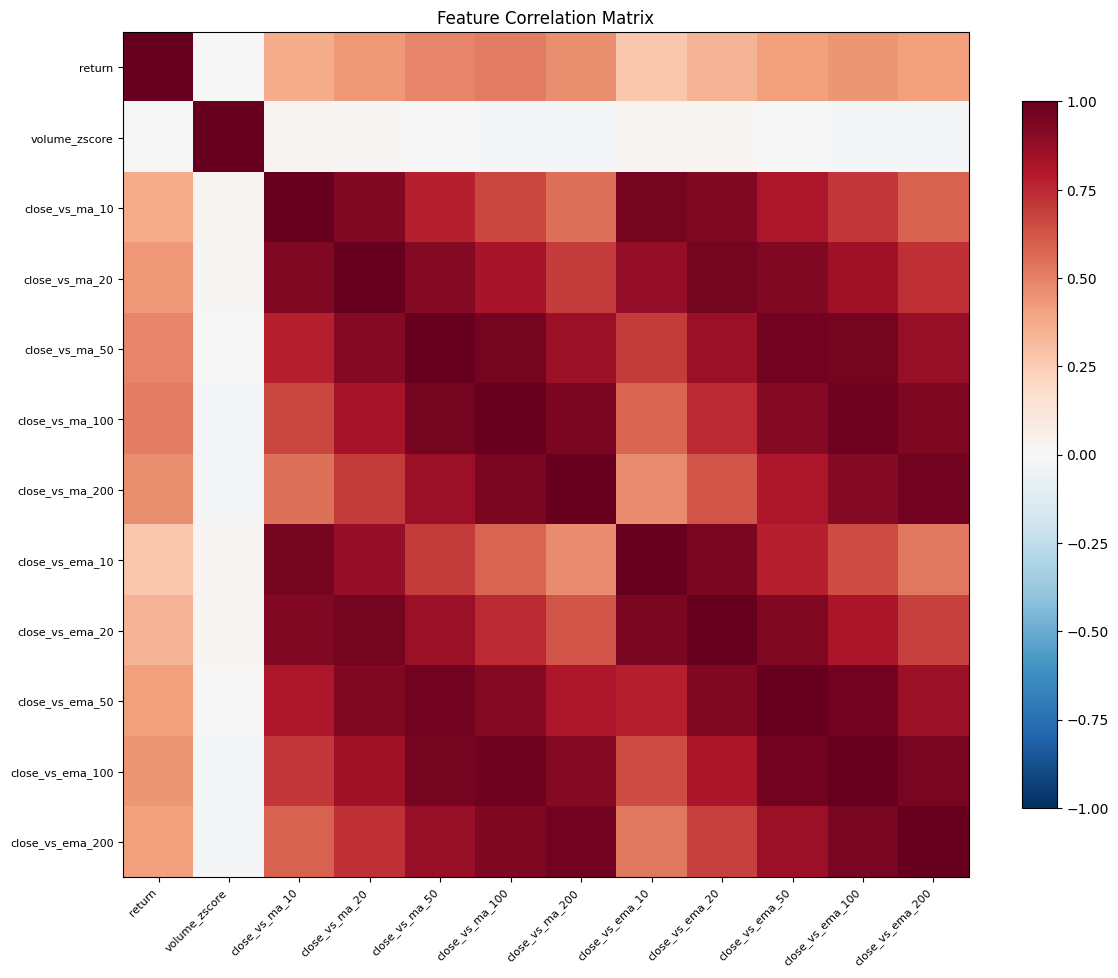

In [10]:
corr = df_feat[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 3. Classification Model — Buy / Hold / Sell

We build a ternary classification target based on next-day returns:
- **BUY (+1)**: next-day return > +0.5%
- **HOLD (0)**: next-day return between -0.5% and +0.5%
- **SELL (-1)**: next-day return < -0.5%

We use a **LightGBM** classifier with a temporal train/test split (no data leakage).

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

FLAT_THRESHOLD = 0.005  # ±0.5%

# Create forward 1-day return as target
df_feat["fwd_return"] = df_feat.groupby("insref")["return"].shift(-1)

# Ternary label
df_feat["target"] = 0  # HOLD
df_feat.loc[df_feat["fwd_return"] >  FLAT_THRESHOLD, "target"] =  1  # BUY
df_feat.loc[df_feat["fwd_return"] < -FLAT_THRESHOLD, "target"] = -1  # SELL

# Drop rows without forward return (last day per instrument)
df_model = df_feat.dropna(subset=["fwd_return"]).copy()

print("Target distribution:")
print(df_model["target"].value_counts().sort_index())
print(f"\nTotal samples: {len(df_model):,}")

Target distribution:
target
-1    1204373
 0     710873
 1    1106246
Name: count, dtype: int64

Total samples: 3,021,492


In [12]:
# Temporal split: train on data before 2024, test on 2024+
SPLIT_DATE = pd.Timestamp("2024-01-01")

train = df_model[df_model["date"] < SPLIT_DATE]
test  = df_model[df_model["date"] >= SPLIT_DATE]

X_train = train[feature_cols]
y_train = train["target"]
X_test  = test[feature_cols]
y_test  = test["target"]

print(f"Train: {len(train):,} rows ({train['date'].min()} to {train['date'].max()})")
print(f"Test:  {len(test):,} rows ({test['date'].min()} to {test['date'].max()})")
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True).sort_index().map('{:.1%}'.format)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True).sort_index().map('{:.1%}'.format)}")

Train: 2,309,230 rows (2015-10-16 00:00:00 to 2023-12-29 00:00:00)
Test:  712,262 rows (2024-01-02 00:00:00 to 2026-03-20 00:00:00)

Train target distribution:
target
-1    39.6%
 0    23.8%
 1    36.5%
Name: proportion, dtype: str

Test target distribution:
target
-1    40.6%
 0    22.6%
 1    36.8%
Name: proportion, dtype: str


In [15]:
# Train a Histogram-based Gradient Boosting classifier (fast on large datasets)
clf = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["SELL (-1)", "HOLD (0)", "BUY (+1)"]))

              precision    recall  f1-score   support

   SELL (-1)       0.45      0.62      0.52    289191
    HOLD (0)       0.39      0.18      0.25    160715
    BUY (+1)       0.43      0.40      0.41    262356

    accuracy                           0.44    712262
   macro avg       0.42      0.40      0.39    712262
weighted avg       0.43      0.44      0.42    712262



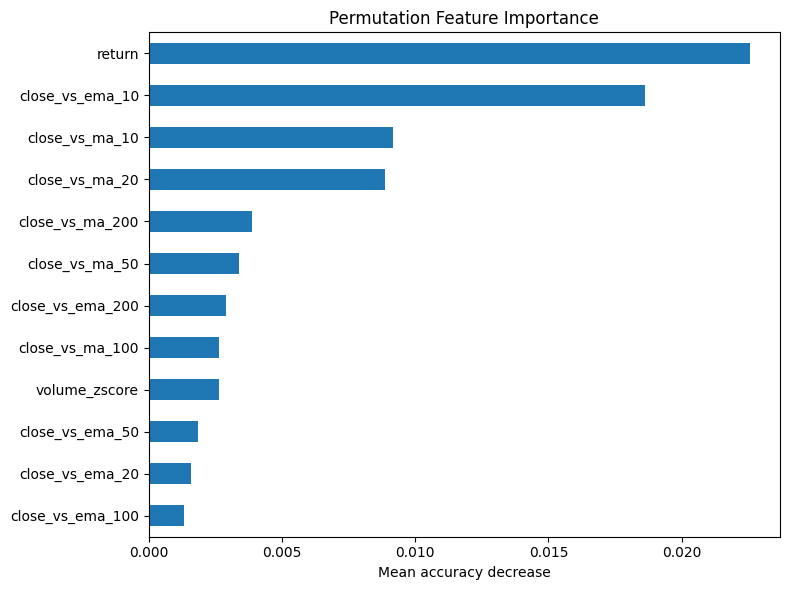

In [17]:
# Feature importance via permutation (works with any estimator)
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(clf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
importances = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax)
ax.set_title("Permutation Feature Importance")
ax.set_xlabel("Mean accuracy decrease")
plt.tight_layout()
plt.show()

## 4. AlphaEval — Evaluate Predictions

Now we feed our model predictions into `alphaeval.evaluate()`.

The library expects a DataFrame with columns:
- `datetime` — timestamp
- `instrument_id` — security identifier
- `return` — daily return
- `y_pred` — prediction: -1 (SELL), 0 (HOLD), +1 (BUY)

In [18]:
from alphaeval import evaluate

# Prepare the input DataFrame for alphaeval
eval_df = test[["date", "insref", "return"]].copy()
eval_df = eval_df.rename(columns={"date": "datetime", "insref": "instrument_id"})
eval_df["y_pred"] = y_pred

print(f"Evaluation set: {len(eval_df):,} rows, {eval_df['instrument_id'].nunique()} instruments")
print(f"Prediction distribution:\n{pd.Series(y_pred).value_counts().sort_index()}")
eval_df.head()

Evaluation set: 712,262 rows, 1549 instruments
Prediction distribution:
-1    392519
 0     75776
 1    243967
Name: count, dtype: int64


,datetime,instrument_id,return,y_pred
2256,2024-01-02,3,0.148718,-1
2257,2024-01-03,3,-0.120536,-1
2258,2024-01-04,3,0.055838,1
2259,2024-01-05,3,0.000000,-1
2260,2024-01-08,3,-0.067308,-1


In [19]:
# Run the full alphaeval evaluation
report = evaluate(
    data=eval_df,
    return_horizons=[1, 5, 10],
    flat_threshold=FLAT_THRESHOLD,
    return_type="simple",
)

print(report.summary())

C:\_git\alphamodel.eval\alphaeval\_evaluate.py:56: UserWarning: Dropped 1549/712262 rows where forward return (horizon=1) could not be computed (end of series).
  df = compute_forward_returns(data, return_horizons, return_type)


alphaeval — Financial Confusion Matrix Report
Horizon: 1d | Flat threshold: 0.005 | Return type: simple | Txn cost: 0.0

                        BUY           HOLD           SELL
--------------------------------------------------------
          Up         103679          22659         135499
        Flat          52361          29430          78608
        Down          87209          23574         177694

Per-Cell P&L Summary:
  Cell           Count    Total P&L      Avg P&L   Max Profit     Max Loss
  --------------------------------------------------------------------
  TP_Long       103679  +10794.6629      +0.1041   +1007.4602      +0.0050
  FN_Up          22659      +0.0000      +0.0000      +0.0000      +0.0000
  FP_Short      135499  -18902.3353      -0.1395      -0.0050   -1826.9570
  CD_Long        52361      -0.0354      -0.0000      +0.0050      -0.0050
  TN             29430      +0.0000      +0.0000      +0.0000      +0.0000
  CD_Short       78608      +7.0950      +0.00

### 4.1 Confusion Matrix (9-cell)

In [20]:
# Display the 9-cell confusion matrix
matrix_data = {k: {"count": v.count, "avg_pnl": v.avg_pnl, "total_pnl": v.total_pnl,
                    "max_profit": v.max_profit, "max_loss": v.max_loss}
               for k, v in report.matrix.items()}
matrix_df = pd.DataFrame(matrix_data).T
matrix_df

,count,avg_pnl,total_pnl,max_profit,max_loss
TP_Long,103679.0,1.041162e-01,10794.662933,1007.460237,0.005000
FN_Up,22659.0,0.000000e+00,0.000000,0.000000,0.000000
FP_Short,135499.0,-1.395017e-01,-18902.335255,-0.005000,-1826.956989
CD_Long,52361.0,-6.756952e-07,-0.035380,0.005000,-0.004998
TN,29430.0,0.000000e+00,0.000000,0.000000,0.000000
CD_Short,78608.0,9.025741e-05,7.094954,0.005000,-0.005000
FP_Long,87209.0,-2.730564e-02,-2381.297342,-0.005000,-0.981854
FN_Down,23574.0,0.000000e+00,0.000000,-0.000000,-0.000000
TP_Short,177694.0,3.547327e-02,6303.387576,0.957577,0.005000


### 4.2 Aggregate Trading Metrics

In [21]:
pd.Series(report.metrics)

expectancy_long                  0.034587
expectancy_short                -0.032138
profit_factor                    0.804808
return_weighted_accuracy         0.442543
gross_profit                 17228.699996
gross_loss                  -21407.222510
win_count                   325050.000000
loss_count                  264335.000000
total_active                635050.000000
dtype: float64

### 4.3 Tail Risk Analysis

In [22]:
pd.Series(report.tail_risk)

FP_Long     {'var': -0.07500000000000007, 'cvar': -0.13026...
FP_Short    {'var': -0.12241731175228716, 'cvar': -2.24894...
dtype: object

### 4.4 Time Decay — Metrics across return horizons (1, 5, 10 days)

In [23]:
# Time decay: see how signal quality degrades over longer horizons
time_decay_rows = []
for direction, horizons in report.time_decay.items():
    for horizon, metrics in horizons.items():
        row = {"direction": direction, "horizon": horizon, **metrics}
        time_decay_rows.append(row)

td_df = pd.DataFrame(time_decay_rows)
td_df

,direction,horizon,count,mean_return,total_pnl,avg_pnl
0,TP_Long,1,103679,1.041162e-01,10794.662933,1.041162e-01
1,TP_Long,5,112612,3.397721e-01,38262.412181,3.397721e-01
2,TP_Long,10,110969,6.481821e-01,71928.120623,6.481821e-01
3,FN_Up,1,22659,1.718122e-02,0.000000,0.000000e+00
4,FN_Up,5,29842,3.222346e-02,0.000000,0.000000e+00
5,FN_Up,10,31693,8.201789e-02,0.000000,0.000000e+00
6,FP_Short,1,135499,1.395017e-01,-18902.335255,-1.395017e-01
7,FP_Short,5,153971,5.496284e-01,-84626.829695,-5.496284e-01
8,FP_Short,10,155447,9.984006e-01,-155198.373746,-9.984006e-01
9,CD_Long,1,52361,-6.756952e-07,-0.035380,-6.756952e-07


### 4.5 Full report as dict

In [24]:
report.to_dict()

{'matrix': {'TP_Long': {'count': 103679,
   'total_pnl': 10794.662932500181,
   'avg_pnl': 0.10411619452830545,
   'max_profit': 1007.4602368866329,
   'max_loss': 0.0050000000000001155},
  'FN_Up': {'count': 22659,
   'total_pnl': 0.0,
   'avg_pnl': 0.0,
   'max_profit': 0.0,
   'max_loss': 0.0},
  'FP_Short': {'count': 135499,
   'total_pnl': -18902.33525540273,
   'avg_pnl': -0.13950165872370077,
   'max_profit': -0.0050000000000001155,
   'max_loss': -1826.9569892473119},
  'CD_Long': {'count': 52361,
   'total_pnl': -0.03538007700429857,
   'avg_pnl': -6.756952121674256e-07,
   'max_profit': 0.004999999999999893,
   'max_loss': -0.004998077662437539},
  'TN': {'count': 29430,
   'total_pnl': 0.0,
   'avg_pnl': 0.0,
   'max_profit': 0.0,
   'max_loss': 0.0},
  'CD_Short': {'count': 78608,
   'total_pnl': 7.094954195776297,
   'avg_pnl': 9.025740631712163e-05,
   'max_profit': 0.004999999999999893,
   'max_loss': -0.004999999999999893},
  'FP_Long': {'count': 87209,
   'total_pnl': 